# Community detection in complex networks

Basics:
* Communities are **locally dense connected subgraphs** in a network.
* Community detection aims to uncover the inherent community structure of a network.

Definitions:
* Clique - a fully connected subgraph within a larger graph.
* Strong community - each node has more edges connecting it to other nodes inside the group than to nodes outside the group.
* Weak community - the total internal degree of the group exceeds its total external degree.

Approaches and algorithms:
* Graph partitioning
* Hierarchical clustering (Girvan–Newman)
* Modularity optimization (Louvain)

## Introduction to community detection

Lets start with a simple example of a small graph.

In [28]:
import networkx as nx

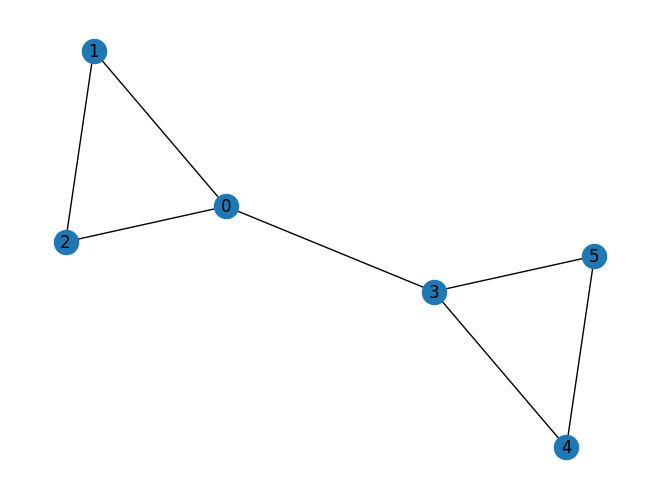

In [29]:
G = nx.Graph()
nx.add_cycle(G, [0, 1, 2])
nx.add_cycle(G, [3, 4, 5])
G.add_edge(0, 3)

nx.draw(G, with_labels=True)

How can we devide this graph into communities to get partitions of good quality? At first we'll do it by hand and validate if the partition is valid.

In [30]:
partition = [
    {0, 1, 2},
    {3, 4, 5},
]

nx.community.is_partition(G, partition)

True

Now, create a mapping between nodes and partitions, that will be of use for visualization and assesment of partition quality.

In [31]:
def create_node_to_partition_mapping(partition):
  node_to_partition = {}
  for idx, cluster_nodes in enumerate(partition):
      for node in cluster_nodes:
          node_to_partition[node] = idx
  return node_to_partition

node_to_partition = create_node_to_partition_mapping(partition)
node_to_partition

{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}

Then visualize this simple graph again with color of nodes corresponding to the partition they belong to.

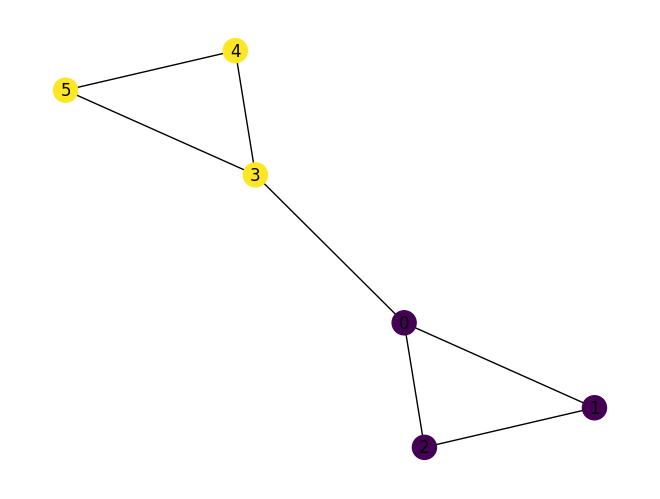

In [32]:
colors = [node_to_partition[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

## Modularity

Now with the defined partition, we need to look for an answer to the question of can we evaluate the goodness of this network partition, and in a broader context, any partition of any graph?

One possible answer is to compare the connection density of the groups to a random baseline, as random networks do not have groups.

The modularity measure is defined as the difference between the number of internal links in the clusters and the expected number of links in a random network.

$$Q = \frac{1}{L}\sum_C(L_C - \frac{k_C^2}{4L})$$

where:
- $L$ - total number of links
- $L_c$ - number of links inside cluster $C$
- $\frac{k_C^2}{4L}$ - number of links in a random network

NetworkX comes with an efficient implementation of modularity calculation ```nx.community.quality.modularity(G, partition)```, that we will use to measure partition quality.

In [33]:
nx.community.quality.modularity(G, partition)

0.35714285714285715

We can verify how the modularity value change if we decide to change the partition.

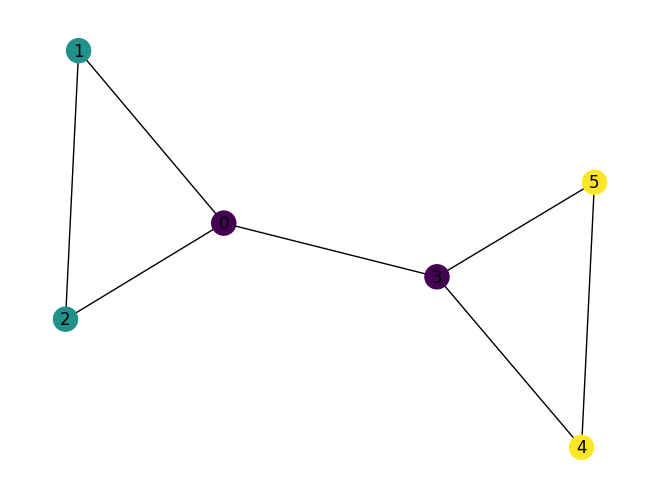

In [34]:
partition2 = [
    {0, 3},
    {1, 2},
    {4, 5},
]

colors = [create_node_to_partition_mapping(partition2)[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

In [35]:
nx.community.quality.modularity(G, partition2)

0.0816326530612245

## Setting up networks for study

In the next sections of this notebook, we will be working with different networks, both artificial and real-world and algorithms that will help us identify communities within those networks.

In [36]:
connected_caveman_graph = nx.connected_caveman_graph(4, 8)
small_world_network = nx.watts_strogatz_graph(34, 4, 0.15)
windmill_graph = nx.windmill_graph(5, 7)
gaussian_random_partition_graph = nx.gaussian_random_partition_graph(n=34, s=9, v=9, p_in=0.7, p_out=0.03, seed=42)
random_partition_graph = nx.random_partition_graph([10, 8, 5, 5, 3, 3], 0.8, 0.04, seed=42)
karate_club_network = nx.karate_club_graph()

### Task 1
The first task is to take a look at the networks that are going to be the subject of study. Prepare a visualization of the graphs defined in the previous cell. Place all of them on a single plot, remember to include subplot titles to be able to identify them and find the best positionig that helps to reveale the network structure.

#### Code

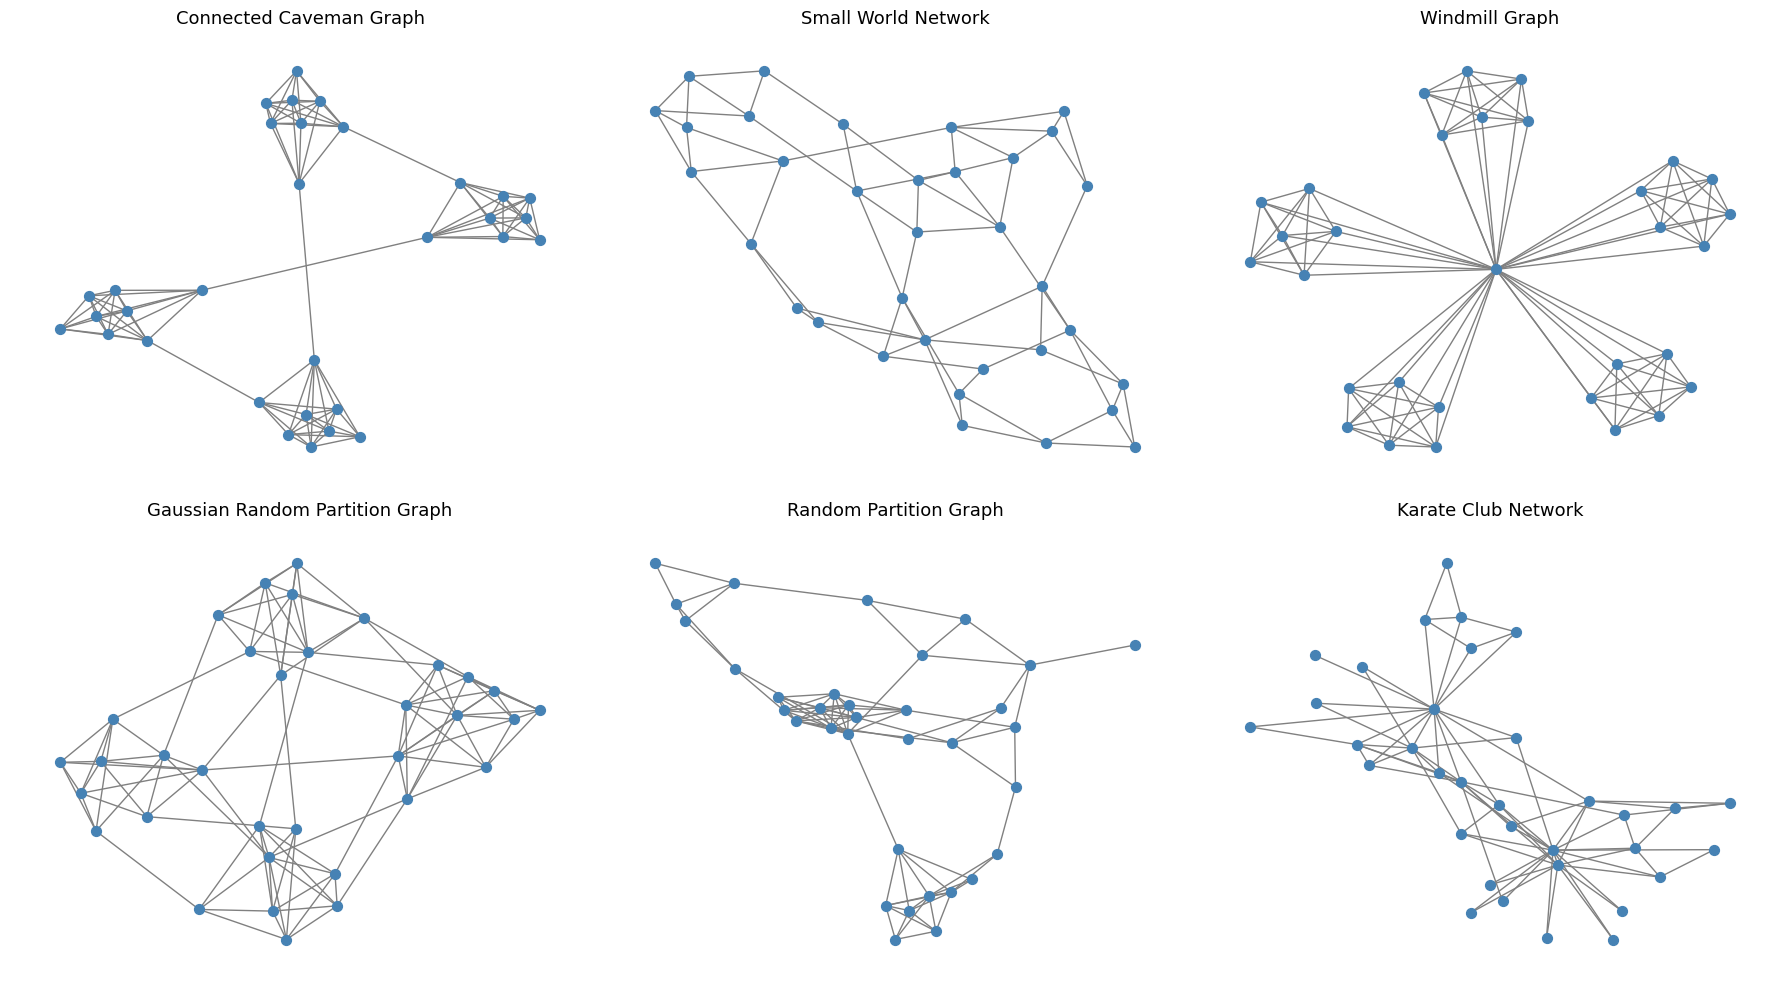

In [37]:
import matplotlib.pyplot as plt

networks = {
    "Connected Caveman Graph": connected_caveman_graph,
    "Small World Network": small_world_network,
    "Windmill Graph": windmill_graph,
    "Gaussian Random Partition Graph": gaussian_random_partition_graph,
    "Random Partition Graph": random_partition_graph,
    "Karate Club Network": karate_club_network,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (title, G) in zip(axes, networks.items()):
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos=pos, ax=ax, with_labels=False, node_size=50, node_color="steelblue", edge_color="gray")
    ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.show()

## Cliques identification

### Task 2
Calculate the number of different size cliques present in each network and visualize them on a barplot.

Analyse and interpret the obtained results, write your conclusions in the cell below. What does the number of cliques says about those networks? Are they differnt or quite similar?

#### Code

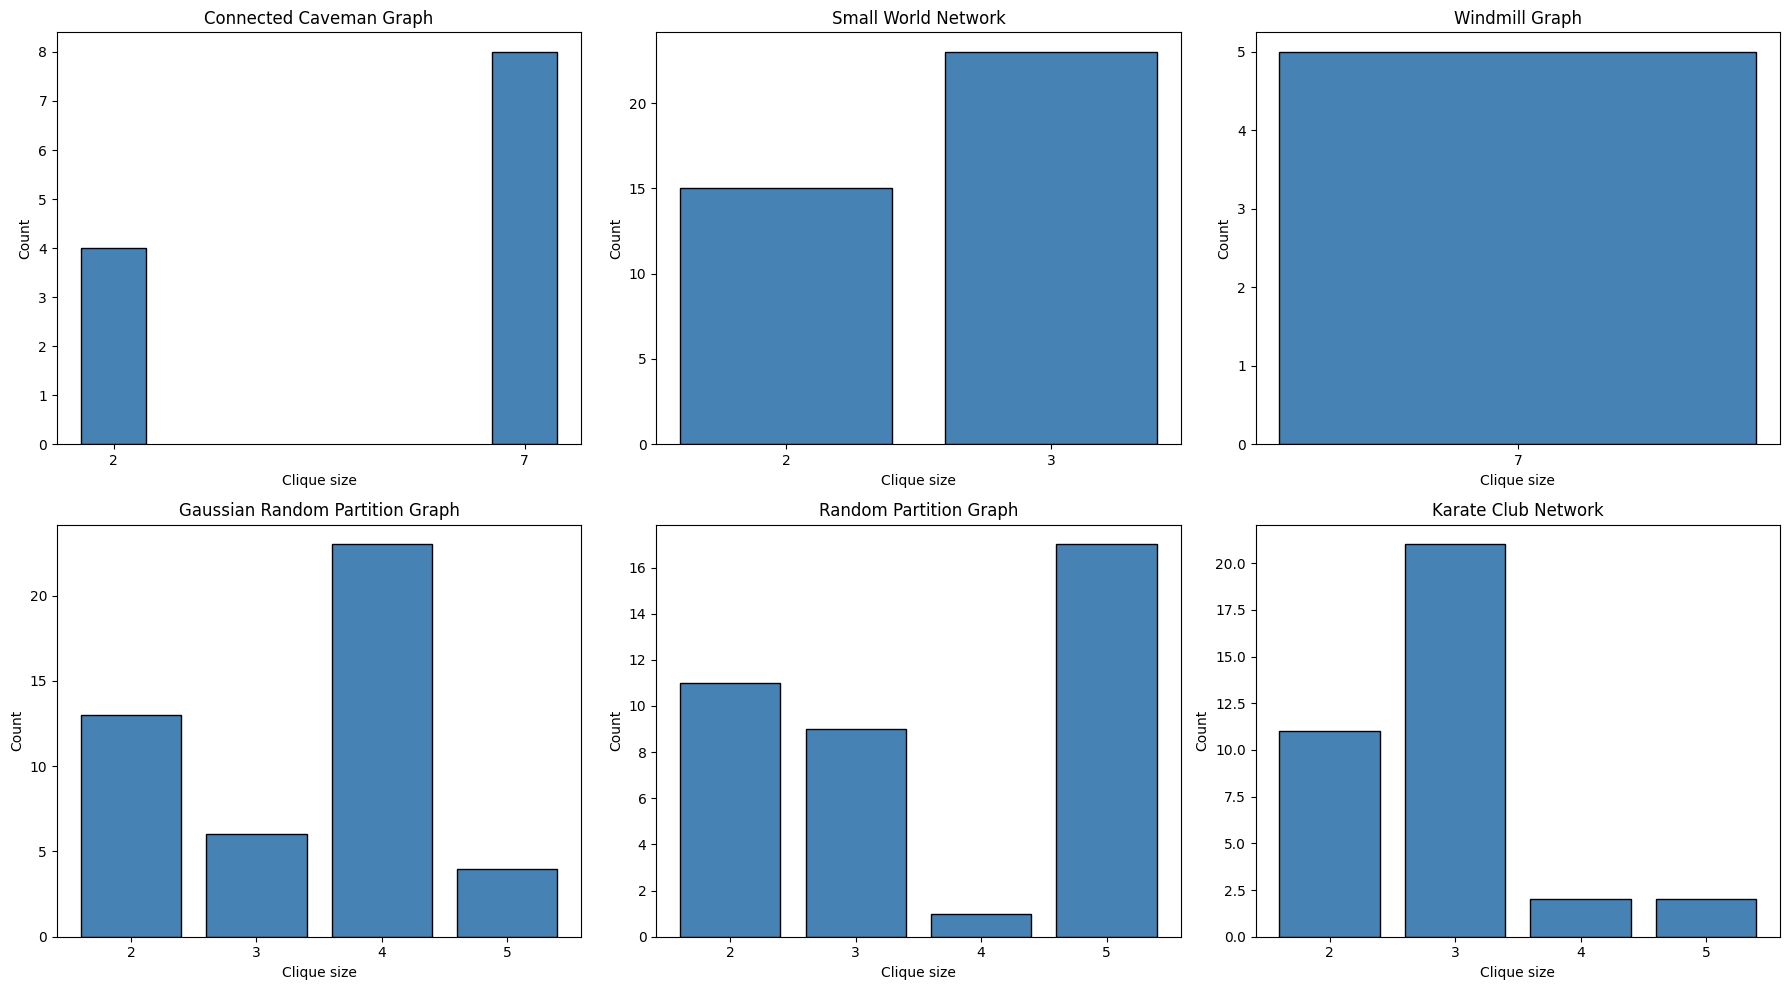

In [38]:
from collections import Counter

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (title, G) in zip(axes, networks.items()):
    clique_sizes = [len(c) for c in nx.find_cliques(G)]
    size_counts = Counter(clique_sizes)

    sizes = list(size_counts.keys())
    counts = list(size_counts.values())

    ax.bar(sizes, counts, color="steelblue", edgecolor="black")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Clique size")
    ax.set_ylabel("Count")
    ax.set_xticks(sizes)

plt.tight_layout()
plt.show()


#### Conclusions

- Caveman ma dwa typy klik - duze (7) będące wewnętrznymi grupami i małe (2) łączące poszczególne grupy
- Small World tworzy co najwyzej trójkąty (brak duzych zbitych grup)
- Windmill ma duze kliki (7), brak mostów w przeciwieństwie do Cavemana, grupy są połączone przez wspólny centralny węzeł
- sieci losowo-partycyjne (Gaussian i Random Partition) mają kliki róznych rozmiarów
- Carate Club - dominują małe kliki (2, 3), ale istnieją tez większe

Im większe i bardziej jednorodne kliki, tym silniejsza i bardziej regularna struktura grafu.

## Hierarchical clustering using Girvan–Newman algorithm

The Girvan–Newman algorithm is a popular method for detecting communities in complex networks. It is based on the concept of edge betweenness centrality and operates by iteratively removing edges with the highest betweenness centrality. This process effectively breaks the network into smaller components, which can then be interpreted as communities.

The algorithm's steps
1. The betweenness of all existing edges in the network is calculated first.
2. The edge(s) with the highest betweenness are removed.
3. The betweenness of all edges affected by the removal is recalculated.
4. Steps 2 and 3 are repeated until no edges remain.

### Task 3
Use Girvan–Newman algorithm to detect communities among all studied networks. Use NetworkX function ```nx.algorithms.community.girvan_newman(G)```. Visualize and inspect obtained results for different numbers of communities. Find the best split for each network using modularity as a goodness measure and plot partitioned networks. Save the modularity results for each network for later comparison with other community detection method.

#### Code

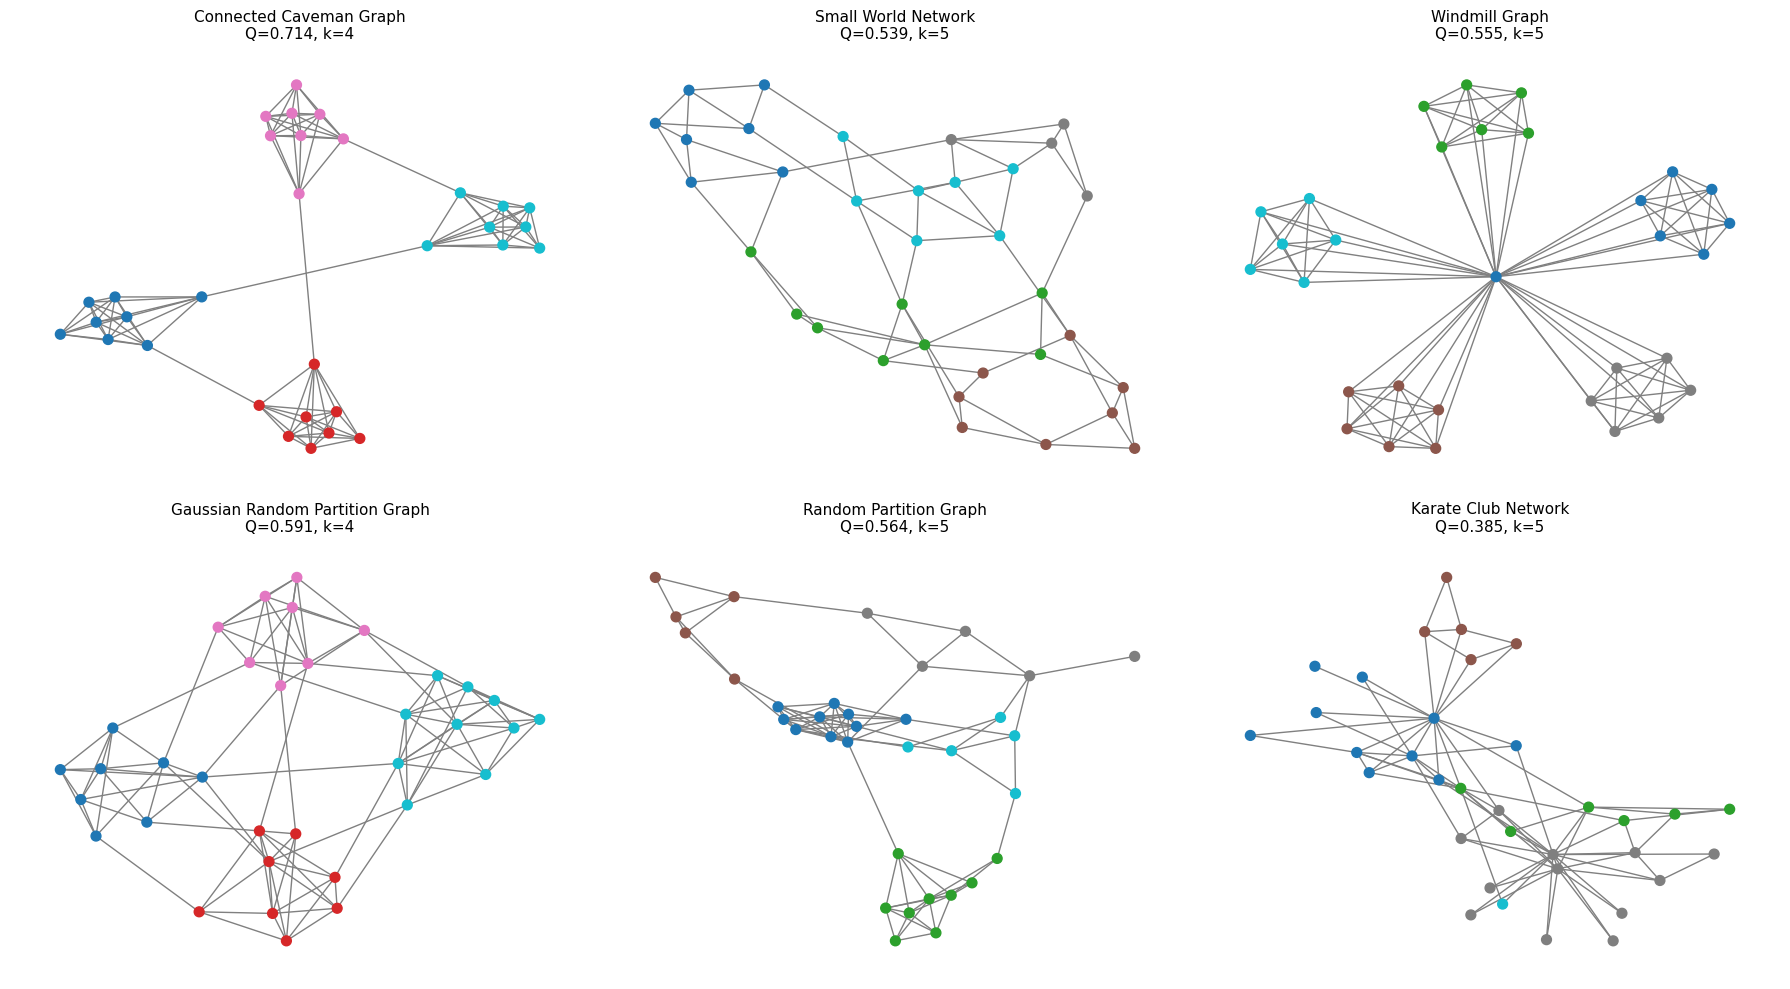


Modularity results (Girvan-Newman):
  Connected Caveman Graph: 0.7143
  Small World Network: 0.5386
  Windmill Graph: 0.5551
  Gaussian Random Partition Graph: 0.5909
  Random Partition Graph: 0.5641
  Karate Club Network: 0.3850


In [39]:
import itertools

gn_modularity_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (title, G) in zip(axes, networks.items()):
    comp = nx.algorithms.community.girvan_newman(G)

    best_partition = None
    best_modularity = -1

    for communities in itertools.islice(comp, 10):
        partition = list(communities)
        q = nx.community.quality.modularity(G, partition)
        if q > best_modularity:
            best_modularity = q
            best_partition = partition

    gn_modularity_results[title] = best_modularity

    node_to_community = {}
    for idx, community in enumerate(best_partition):
        for node in community:
            node_to_community[node] = idx

    colors = [node_to_community[n] for n in G.nodes]
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos=pos, ax=ax, node_color=colors, cmap=plt.cm.tab10,
            with_labels=False, node_size=50, edge_color="gray")
    ax.set_title(f"{title}\nQ={best_modularity:.3f}, k={len(best_partition)}", fontsize=11)

plt.tight_layout()
plt.show()

print("\nModularity results (Girvan-Newman):")
for name, q in gn_modularity_results.items():
    print(f"  {name}: {q:.4f}")


## Modularity based community detection using Louvain algorithm
The Louvain algorithm is the most popular community detection algorithm. Its operation is based on the optimization of modularity. Louvain can be used even with very large networks with millions of nodes and edges.

### Louvain algorithm
1. Start with each node assigned to its own group.
2. Loop over nodes:

  2.1. Assign the node to the neighbor community that will give you the largest modularity increase.

  2.2. Repeat step 2.1 until no further modularity increase is possible.
3. Transform your network into a super network.

  3.1. Each community becomes a supernode.

  3.2. Assign weights to the edges corresponding to the number of connections within and between the groups.
4. Repeat step 2 until no further modularity increase is possible.


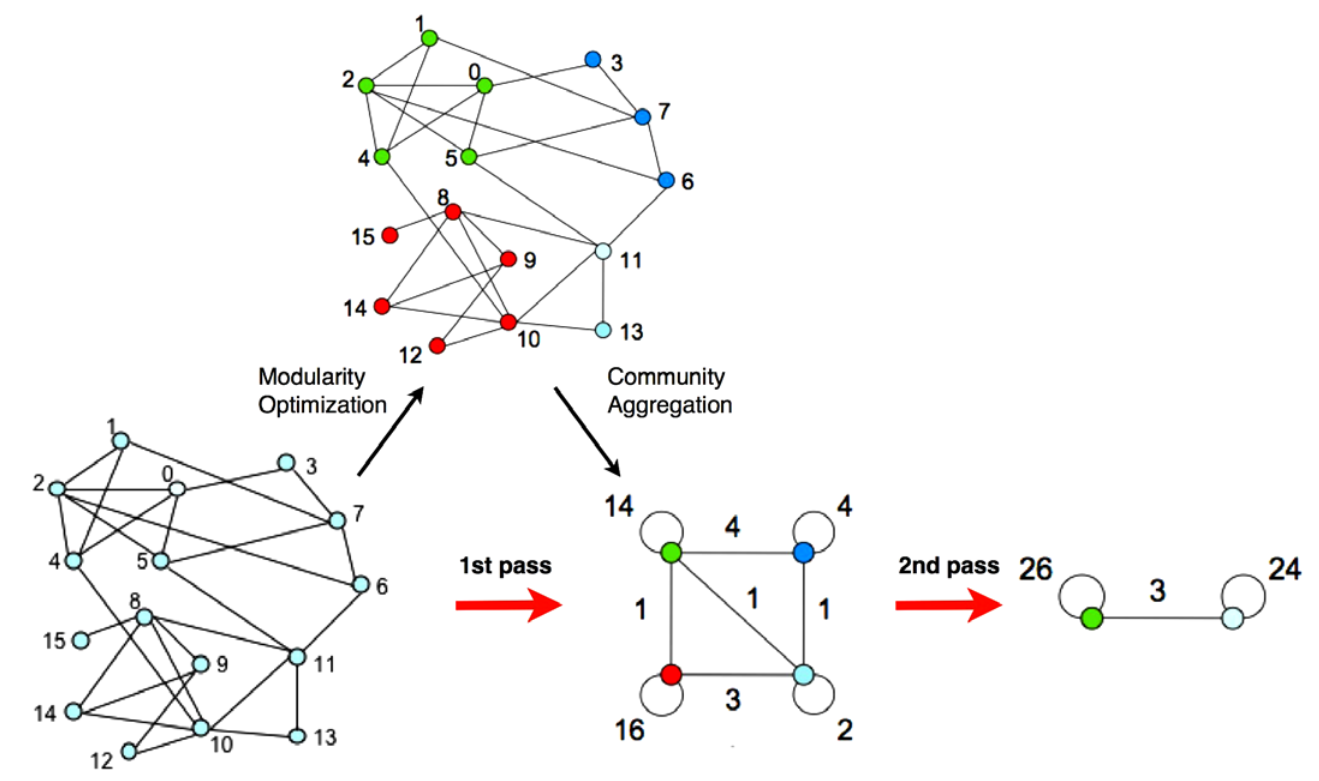

### Task 4
Use Louvain algorithm to detect communities among all studied networks. Use NetworkX function ```nx.community.louvain_communities(G, seed)```. Visualize and inspect the results.

Analyse and interpret the obtained communities, write your conclusions in the cell below.

 - Can we consider the produced split an optimal one? Change the seed value and check how it influences the obtained results, can you explain why the splits are sometimes different?

 - Compare the modularity value for generated partitions between Louvain algorithm and Girvan-Newmann algorithm. Which one is better in your opinion?

#### Code

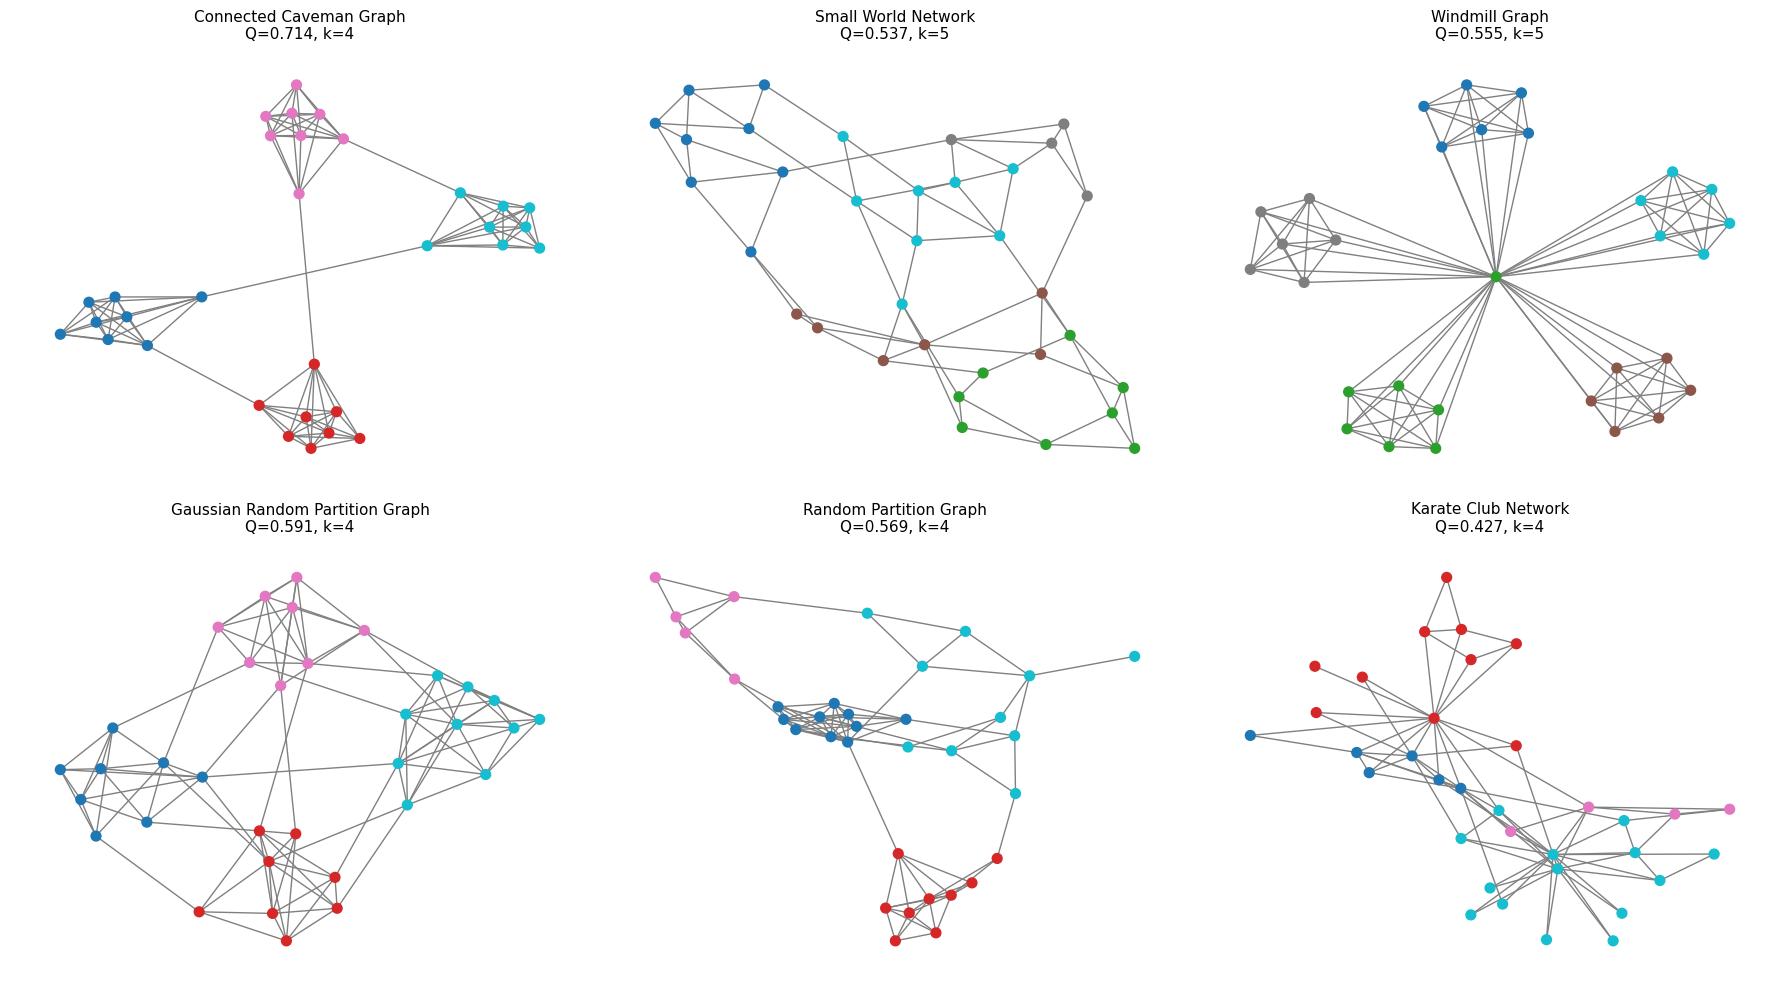

Network                           Girvan-Newman Q    Louvain Q
--------------------------------------------------------------
Connected Caveman Graph                    0.7143       0.7143
Small World Network                        0.5386       0.5372
Windmill Graph                             0.5551       0.5551
Gaussian Random Partition Graph             0.5909       0.5909
Random Partition Graph                     0.5641       0.5694
Karate Club Network                        0.3850       0.4266


In [40]:
from networkx.algorithms.community import louvain_communities

louvain_modularity_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (title, G) in zip(axes, networks.items()):
    partition = louvain_communities(G, seed=42)
    q = nx.community.quality.modularity(G, partition)
    louvain_modularity_results[title] = q

    node_to_comm = {}
    for idx, community in enumerate(partition):
        for node in community:
            node_to_comm[node] = idx

    colors = [node_to_comm[n] for n in G.nodes()]
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos=pos, ax=ax, node_color=colors, cmap=plt.cm.tab10,
            with_labels=False, node_size=50, edge_color="gray")
    ax.set_title(f"{title}\nQ={q:.3f}, k={len(partition)}", fontsize=11)

plt.tight_layout()
plt.show()

print(f"{'Network':<30} {'Girvan-Newman Q':>18} {'Louvain Q':>12}")
print("-" * 62)
for name in networks:
    gn_q = gn_modularity_results.get(name, float('nan'))
    lv_q = louvain_modularity_results.get(name, float('nan'))
    print(f"{name:<30} {gn_q:>18.4f} {lv_q:>12.4f}")

#### Conclusions

- dla większosci sieci oba algorytmy dają takie same, albo bardzo zblizone Q (wykrywają te same struktury)
- Louvain daje wyzsze Q dla Karate Club Network, lepiej radzi sobie z nieregularnymi sieciami realnymi
- Girvan-Newman daje nieco lepszy wynik dla Small World Network - usuwanie krawędzi mostowych dobrze działa w sieciach z luźnymi połączeniami między grupami

Wybór algorytmu ma znaczenie głównie dla sieci realnych. Dla sieci sztucznych z wyraźną strukturą oba algorytmy dają podobne wyniki.

## Modularity,  communities and the graph structure

### Task 5
Generate a set of artificial networks of different types (scale-free netowrks, small-world networks, random partition graphs, ...) and with varying properties (size, connectivity, ...).

Study the relationship between network metrics like average centrality measures (degree, betweenness, closeness), clustering coefficient, etc. and modularity value of partition generated with Louvain algorithm as well as number of identified communities.

Analyse and interpret the obtained results, write your conclusions in the cell below.

#### Code

In [41]:
import pandas as pd

test_networks = {
    # scale-free (Barabasi–Albert)
    "BA n=50 m=2":   nx.barabasi_albert_graph(50, 2, seed=42),
    "BA n=100 m=2":  nx.barabasi_albert_graph(100, 2, seed=42),
    "BA n=100 m=5":  nx.barabasi_albert_graph(100, 5, seed=42),
    # small-world (Watts–Strogatz)
    "WS n=50 p=0.1":  nx.watts_strogatz_graph(50, 4, 0.1, seed=42),
    "WS n=50 p=0.5":  nx.watts_strogatz_graph(50, 4, 0.5, seed=42),
    "WS n=100 p=0.1": nx.watts_strogatz_graph(100, 4, 0.1, seed=42),
    # random partition
    "RP p_in=0.8":  nx.random_partition_graph([15,15,15], 0.8, 0.02, seed=42),
    "RP p_in=0.5":  nx.random_partition_graph([15,15,15], 0.5, 0.05, seed=42),
    "RP p_in=0.9":  nx.random_partition_graph([20,20,20], 0.9, 0.01, seed=42),
    # random (Erdos–Renyi)
    "ER n=50 p=0.1":  nx.erdos_renyi_graph(50, 0.1, seed=42),
    "ER n=50 p=0.3":  nx.erdos_renyi_graph(50, 0.3, seed=42),
}

rows = []
for name, G_test in test_networks.items():
    G_test = G_test.subgraph(max(nx.connected_components(G_test), key=len)).copy()
    
    partition = louvain_communities(G_test, seed=42)
    q = nx.community.quality.modularity(G_test, partition)
    n_communities = len(partition)
    
    rows.append({
        "Network": name,
        "Nodes": G_test.number_of_nodes(),
        "Edges": G_test.number_of_edges(),
        "Avg Degree": round(sum(dict(G_test.degree()).values()) / G_test.number_of_nodes(), 3),
        "Avg Betweenness": round(sum(nx.betweenness_centrality(G_test).values()) / G_test.number_of_nodes(), 4),
        "Avg Closeness": round(sum(nx.closeness_centrality(G_test).values()) / G_test.number_of_nodes(), 4),
        "Clustering Coeff": round(nx.average_clustering(G_test), 4),
        "Modularity Q": round(q, 4),
        "Communities": n_communities,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

       Network  Nodes  Edges  Avg Degree  Avg Betweenness  Avg Closeness  Clustering Coeff  Modularity Q  Communities
   BA n=50 m=2     50     96       3.840           0.0312         0.4079            0.2609        0.4084            6
  BA n=100 m=2    100    196       3.920           0.0189         0.3569            0.1634        0.4468            9
  BA n=100 m=5    100    475       9.500           0.0119         0.4654            0.2125        0.2334            7
 WS n=50 p=0.1     50    100       4.000           0.0550         0.2767            0.3433        0.6131            7
 WS n=50 p=0.5     50    100       4.000           0.0409         0.3394            0.1376        0.4631            5
WS n=100 p=0.1    100    200       4.000           0.0399         0.2058            0.3830        0.7161           10
   RP p_in=0.8     45    256      11.378           0.0271         0.4650            0.7000        0.6032            3
   RP p_in=0.5     45    188       8.356           0.026

#### Conclusions

- BA -  więcej krawędzi na węzeł = słabsze społeczności (Q spada)
- WS - najwyższe Q — regularna siatka naturalnie tworzy silne skupienia, wyższe p rozmywa tę strukturę
- RP - wszystkie 3 zaprojektowane grupy wykryte we wszystkich wariantach, wyższe p_in = wyższe Q.
- ER - najniższe klastrowanie i Q — losowe połączenia nie tworzą skupień

## Real world data use-case
The data is a history of internal e-mail communication (`sender, recipient, datetime`) between employees of a mid-sized manufacturing company. Multiple recipients of the same e-mail (`To, CC, BCC`) are represented as separate rows without distinguishing the recipient type. The period covered are nine full months (event dates in local time). The file containing the communication events is named `communication.csv`.

Apart from the communication, information about who in the company reports to whom is attached (`reportsto.csv`). Node #86 is CEO.

### Data preparation

In [42]:
!apt install libgraphviz-dev
!pip install pygraphviz

zsh:1: command not found: apt

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Load raw events data

In [43]:
import requests
from pathlib import Path

data_file = Path("communication.tab")
if not data_file.exists():
    r = requests.get("https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/KWTRDM")
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ''))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

raw_df = pd.read_table(data_file, sep=';', header=0,  parse_dates=["EventDate"])

Load company hierarchy

In [44]:
data_file = Path("reportsto.tab")
if not data_file.exists():
    r = requests.get("https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/SMALXX")
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ''))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

reportsto = pd.read_csv(data_file, sep=";")

Clean dataset

In [45]:
non_employee_accounts = reportsto[reportsto.ReportsToID.apply(lambda x: not x.isnumeric())]
rows_to_remove = raw_df.loc[raw_df["Sender"].isin(non_employee_accounts["ID"]) | raw_df["Recipient"].isin(non_employee_accounts["ID"])]
raw_df = raw_df.drop(rows_to_remove.index)
reportsto = reportsto.drop(non_employee_accounts.index)

Plot company hierarchy

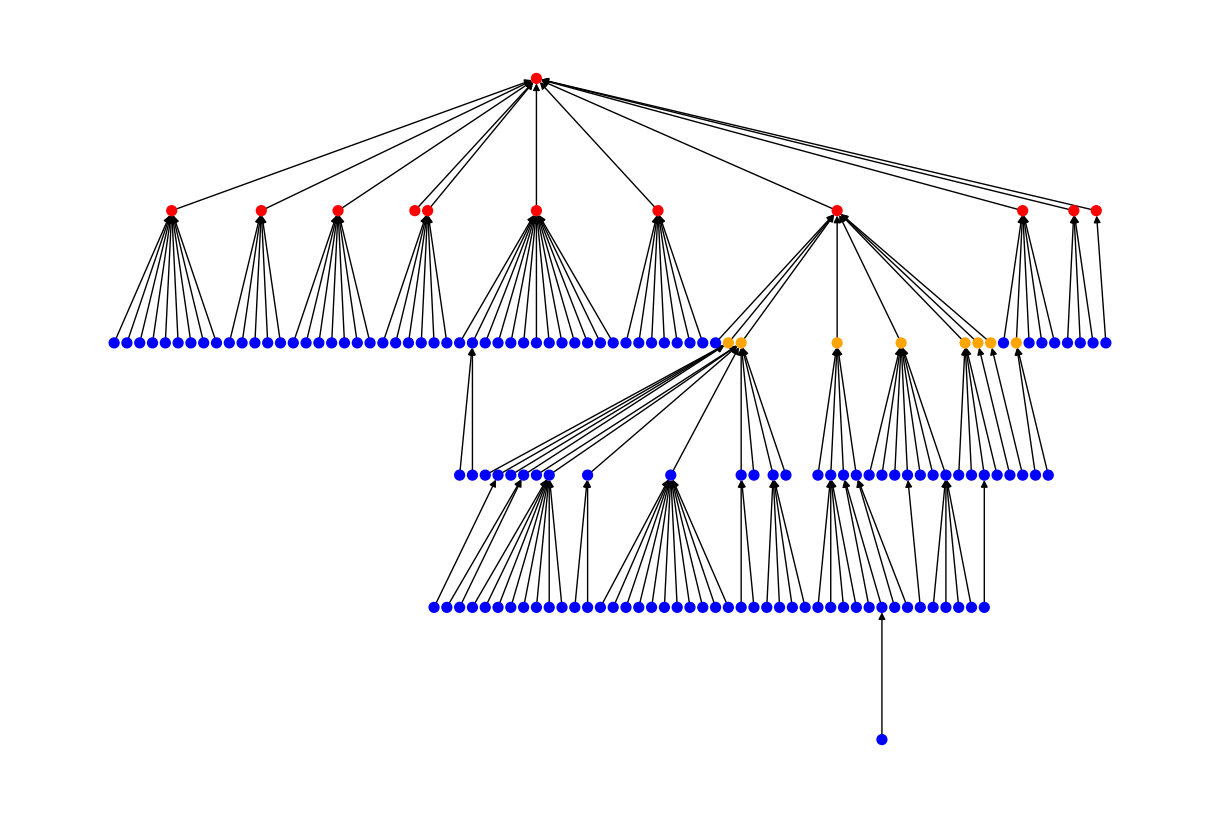

In [46]:
first_management_level = [86, 7, 27, 36, 69, 70, 85, 104, 121, 148, 156, 163]
second_management_level = [76, 90, 136, 137, 143, 152, 47, 162]

H = nx.DiGraph()

for index, row in reportsto.iterrows():
  employee = row['ID']
  supervisor = int(row['ReportsToID'])
  communication_nodes = set(raw_df["Sender"].values + raw_df["Recipient"].values)
  if employee != supervisor and (employee in communication_nodes or supervisor in communication_nodes):
    H.add_edge(employee, supervisor)

color_map = []
for node in H:
  if node in first_management_level:
    color_map.append("red")
  elif node in second_management_level:
    color_map.append("orange")
  else:
    color_map.append("blue")

plt.figure(figsize=(12, 8))
pos_hierarchic = nx.nx_agraph.graphviz_layout(H, prog='dot')
pos_hierarchic = {node: (x,-y) for (node, (x,y)) in pos_hierarchic.items()}
nx.draw(H, pos=pos_hierarchic, with_labels=False, arrows=True, node_size=50, node_color=color_map)

plt.show()

### Task 6
Create a weighted network from the communication data (see Section "Data preparation above").
Check if you can find communities in this real world network. Try different algorithms and approaches.

Can weight of the edges be used in that context? What type of graph representation can be an input to the community detection method you use?

Visualize communities using hirarchy positioning defined in the cell above. For the clarity of visualizations, use only edges from hierarchy company structure.

Analyse and interpret the obtained results, write your conclusions in the cell below. Answer the question: How can this kind of network analysis and exploration be leveraged in the company to improve its functioning?

#### Code

##### Network creation

In [47]:
edge_df = raw_df[["Sender", "Recipient"]].copy()
edge_df["u"] = edge_df[["Sender", "Recipient"]].min(axis=1)
edge_df["v"] = edge_df[["Sender", "Recipient"]].max(axis=1)
edge_df = edge_df[edge_df["u"] != edge_df["v"]]
weighted_edges = edge_df.groupby(["u", "v"]).size().reset_index(name="weight")

G_comm = nx.Graph()
for _, row in weighted_edges.iterrows():
    G_comm.add_edge(int(row["u"]), int(row["v"]), weight=int(row["weight"]))

lcc = max(nx.connected_components(G_comm), key=len)
G_comm = G_comm.subgraph(lcc).copy()
print(f"Communication network: {G_comm.number_of_nodes()} nodes, {G_comm.number_of_edges()} edges")

Communication network: 153 nodes, 3190 edges


##### Community detection

In [48]:
# Louvain with weights
partition_w = louvain_communities(G_comm, weight="weight", seed=42)
q_w = nx.community.quality.modularity(G_comm, partition_w, weight="weight")
print(f"Louvain (weighted):   Q={q_w:.4f}, communities={len(partition_w)}")

Louvain (weighted):   Q=0.3933, communities=7


In [49]:
# Louvain without weights
partition_uw = louvain_communities(G_comm, weight=None, seed=42)
q_uw = nx.community.quality.modularity(G_comm, partition_uw)
print(f"Louvain (unweighted): Q={q_uw:.4f}, communities={len(partition_uw)}")

Louvain (unweighted): Q=0.2153, communities=4


##### Visualization

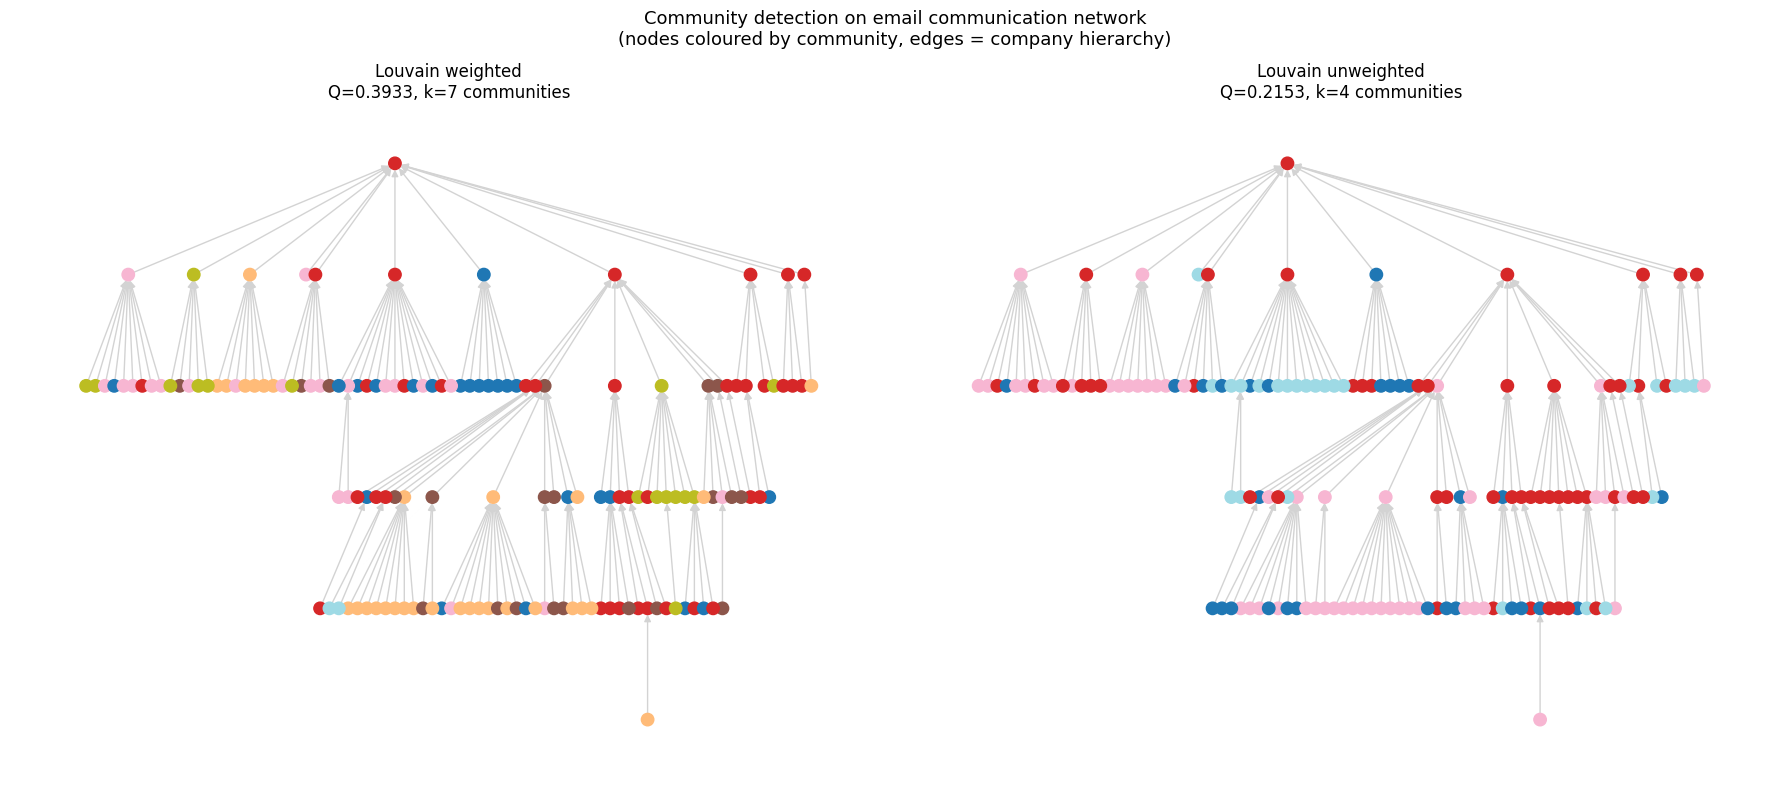

In [50]:
node_to_comm_w  = {node: idx for idx, comm in enumerate(partition_w)  for node in comm}
node_to_comm_uw = {node: idx for idx, comm in enumerate(partition_uw) for node in comm}

common_nodes = [n for n in H.nodes() if n in G_comm.nodes()]
H_sub = H.subgraph(common_nodes)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (label, node_to_comm, q, partition) in zip(axes, [
    ("Louvain weighted",   node_to_comm_w,  q_w,  partition_w),
    ("Louvain unweighted", node_to_comm_uw, q_uw, partition_uw),
]):
    node_colors = [node_to_comm.get(n, -1) for n in H_sub.nodes()]
    pos_sub = {n: pos_hierarchic[n] for n in H_sub.nodes() if n in pos_hierarchic}
    nx.draw(
        H_sub, pos=pos_sub, ax=ax,
        node_color=node_colors, cmap=plt.cm.tab20,
        with_labels=False, node_size=80,
        edge_color="lightgray", arrows=True,
    )
    ax.set_title(f"{label}\nQ={q:.4f}, k={len(partition)} communities", fontsize=12)

plt.suptitle("Community detection on email communication network\n(nodes coloured by community, edges = company hierarchy)", fontsize=13)
plt.tight_layout()
plt.show()

#### Conclusions


- sieć ma 153 węzły i 3190 krawędzi — komunikacja w firmie jest intensywna
- Louvain wymaga nieskierowanego grafu (ważonego lub nie) — emaile zamieniliśmy na nieskierowane krawędzie z wagą równą liczbie wiadomości między parą osób
- Louvain z wagami (Q=0.39) wykrył 7 społeczności — uwzględnienie częstotliwości komunikacji daje lepszy obraz niż samo czy w ogóle pisali do siebie
- Louvain bez wag (Q=0.22) wykrył tylko 4 społeczności — słabsza modularity, grupy mniej wyraźne
- na wizualizacji wiele gałęzi hierarchii firmowej odpowiada jednej społeczności — komunikacja często pokrywa się ze strukturą organizacyjną
- są jednak węzły należące do społeczności z innej gałęzi hierarchii — to nieformalne powiązania między działami
- zastosowanie w firmie: wykrywanie silosów informacyjnych, znajdowanie osób łączących wiele grup oraz weryfikacja czy struktura formalna odpowiada temu, jak praca naprawdę się odbywa
